In [1]:
import numpy as np
import xarray as xr
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean as cm
from scipy.signal import welch, detrend, get_window
from scipy.signal import spectrogram
from scipy.ndimage import binary_dilation
from swot_analysis import plotting

In [2]:
#Loading individual granule file
#data_dir = "/Users/zoecas/Documents/data/SWOT_L2_LR_SSH_BASIC_D_D-20260603_062409/"
if True:
    data_dir = Path('/Users/zoecas/Documents/data/')
    files = list(sorted(data_dir.glob('SWOT_563/SWOT_L2_LR_SSH_*.nc')))
    #files_bis = list(sorted(data_dir.glob('SWOT_354/SWOT_L2_LR_SSH_*.nc')))
    print(f'Found {len(list(files))} files')

Found 17 files


In [3]:
files

[PosixPath('/Users/zoecas/Documents/data/SWOT_563/SWOT_L2_LR_SSH_Basic_034_563_20250628T201439_20250628T210607_PID0_01.nc'),
 PosixPath('/Users/zoecas/Documents/data/SWOT_563/SWOT_L2_LR_SSH_Basic_035_563_20250719T165945_20250719T175113_PID0_01.nc'),
 PosixPath('/Users/zoecas/Documents/data/SWOT_563/SWOT_L2_LR_SSH_Basic_036_563_20250809T134448_20250809T143616_PID0_01.nc'),
 PosixPath('/Users/zoecas/Documents/data/SWOT_563/SWOT_L2_LR_SSH_Basic_037_563_20250830T102954_20250830T112122_PID0_01.nc'),
 PosixPath('/Users/zoecas/Documents/data/SWOT_563/SWOT_L2_LR_SSH_Basic_038_563_20250920T071455_20250920T080623_PID0_01.nc'),
 PosixPath('/Users/zoecas/Documents/data/SWOT_563/SWOT_L2_LR_SSH_Basic_039_563_20251011T040001_20251011T045129_PID0_01.nc'),
 PosixPath('/Users/zoecas/Documents/data/SWOT_563/SWOT_L2_LR_SSH_Basic_040_563_20251101T004507_20251101T013635_PID0_01.nc'),
 PosixPath('/Users/zoecas/Documents/data/SWOT_563/SWOT_L2_LR_SSH_Basic_041_563_20251121T213010_20251121T222138_PID0_01.nc'),


In [4]:
#Combining netCDF files in xarray datasets
datasets = [xr.open_dataset(f) for f in files] #opening files
datasets = [d.where(np.abs(d.ssha_karin)<2.5) for d in datasets] # Removing abnormal values
# True if crossover (two passes)
if False:
    datasets_bis = [xr.open_dataset(f) for f in files_bis] #opening files
    datasets_bis = [d.where(np.abs(d.ssha_karin)<2.5) for d in datasets_bis] # Removing abnormal values
#_ds = xr.concat(datasets, dim='cycles') #concatenating along tracks

In [5]:
# True if crossover (two passes)
if True:
    _ds = xr.concat(datasets,dim='cycles')
if False:
    _ds = xr.combine_nested([datasets,datasets_bis],concat_dim=['passes','cycles'])

In [44]:
_ds

<xarray.Dataset> Size: 2GB
Dimensions:                                (cycles: 17, num_lines: 9866,
                                            num_pixels: 69, num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: cycles, num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (cycles, num_lines, num_pixels) datetime64[ns] 93MB ...
    time_tai                               (cycles, num_lines, num_pixels) datetime64[ns] 93MB ...
    ssh_karin                              (cycles, num_lines, num_pixels) float64 93MB ...
    ssh_karin_qual                         (cycles, num_lines, num_pixels) float64 93MB ...
    ssh_karin_uncert                       (cycles, num_lines, num_pixels) float64 93MB ...
    ssha_karin                             (cycles, num_lines, num_pixels) float64 93MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (cycles, num_lines, num_pixels) float64 93MB ...
    mean_sea_surface_cnescls_uncert        (cycles, num_lines, num_pixels) float64 93MB ...
    geoid                                  (cycles, num_lines, num_pixels) float64 93MB ...
    internal_tide_hret                     (cycles, num_lines, num_pixels) float64 93MB ...
    height_cor_xover                       (cycles, num_lines, num_pixels) float64 93MB ...
    height_cor_xover_qual                  (cycles, num_lines, num_pixels) float32 46MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2025-06-30T22:08:15Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       69.87328120787274
    ssha_variance:                                 0.30965934203753476
    references:                                    V1.4.1
    equator_longitude:                             -75.03

In [6]:
ssha = (_ds.ssha_karin_2+_ds.height_cor_xover+_ds.internal_tide_hret).where(_ds.ssha_karin_2_qual==0)
ssha = ssha - ssha.mean(['num_lines','num_pixels'])

In [7]:
_ds.time.mean(dim=['num_lines','num_pixels'])

<xarray.DataArray 'time' (cycles: 17)> Size: 136B
array(['2025-06-28T20:37:31.939599454', '2025-07-19T17:22:27.919174890',
       '2025-08-09T14:09:11.291122356', '2025-08-30T10:54:07.989128896',
       '2025-09-20T07:39:28.898017732', '2025-10-11T04:24:57.236899636',
       '2025-11-01T01:09:54.387186228', '2025-11-21T21:53:44.165226788',
       '2025-12-12T18:38:33.755790484', '2026-01-02T15:23:26.162792312',
       '2026-01-23T12:08:22.446036088', '2026-02-13T08:53:10.236629912',
       '2026-03-06T05:39:42.327178712', '2026-03-27T02:23:14.828960312',
       '2026-04-16T23:08:29.175711664', '2026-05-07T19:53:33.026813936',
       '2026-05-28T16:38:49.763937944'], dtype='datetime64[ns]')
Dimensions without coordinates: cycles
Attributes:
    long_name:           time in UTC
    standard_name:       time
    tai_utc_difference:  37.0
    leap_second:         0000-00-00T00:00:00Z
    comment:             Time of measurement in seconds in the UTC time scale...

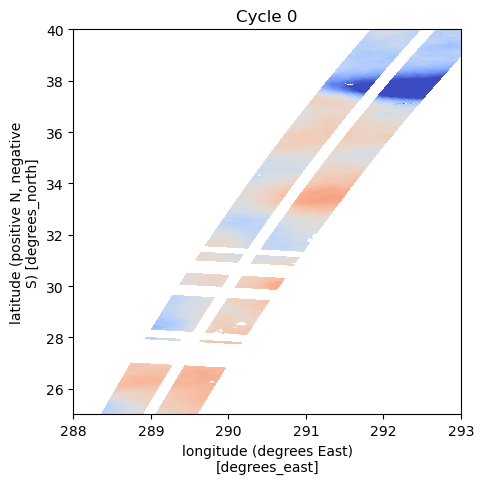

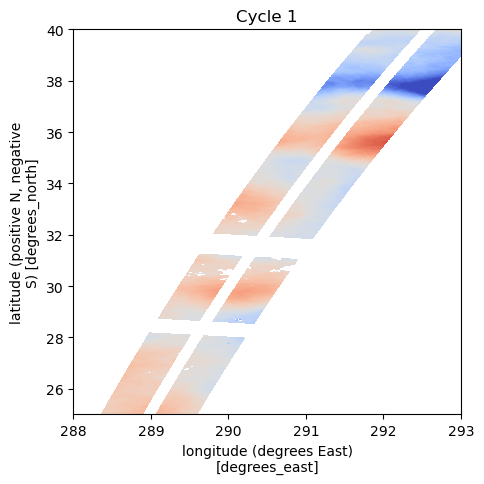

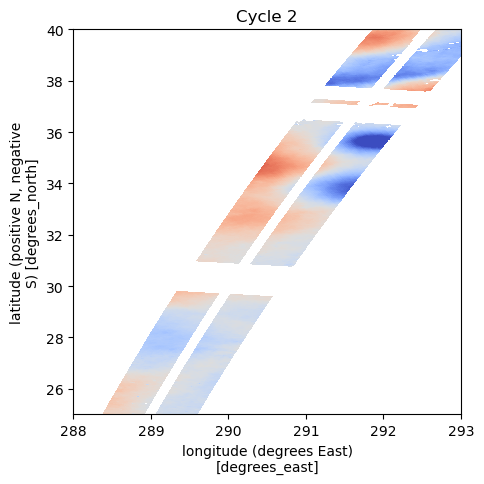

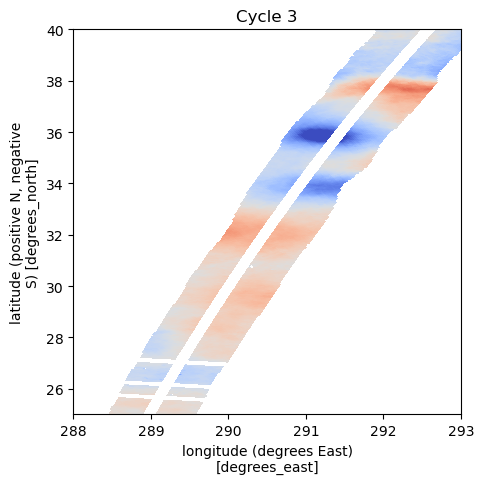

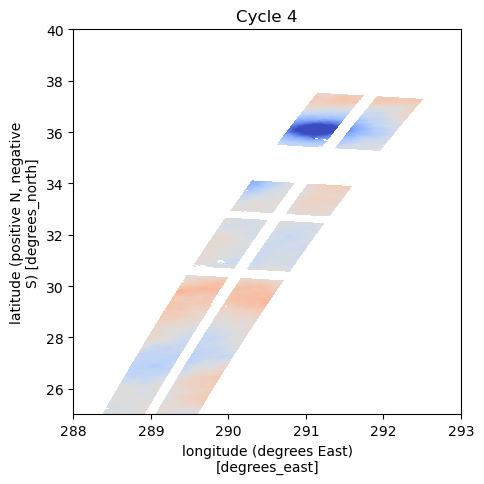

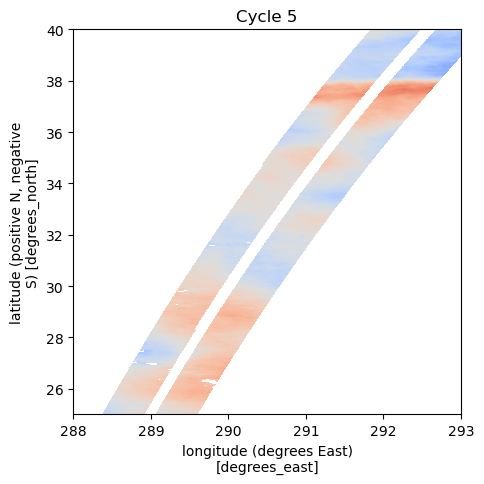

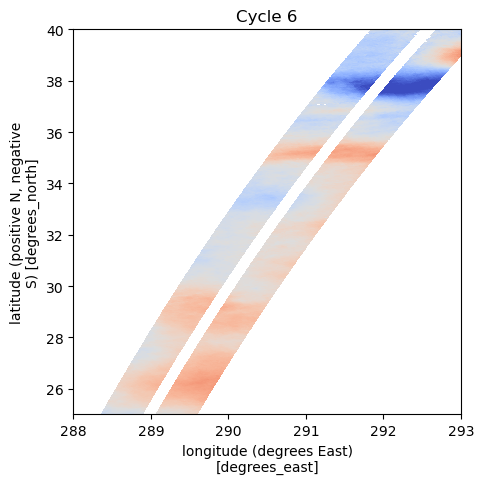

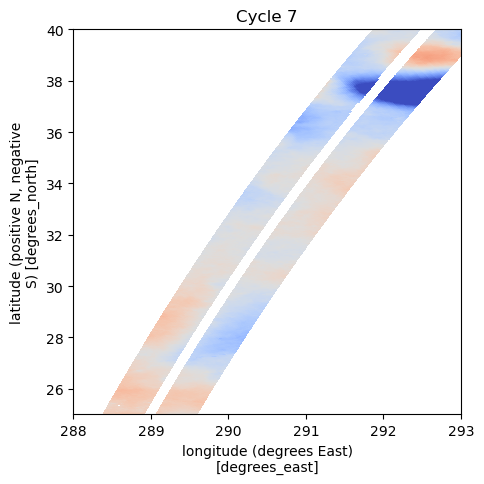

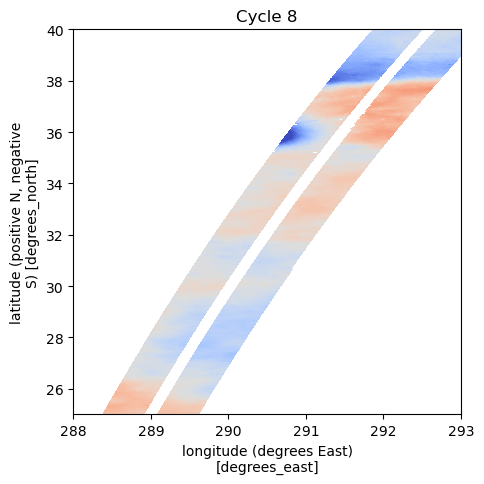

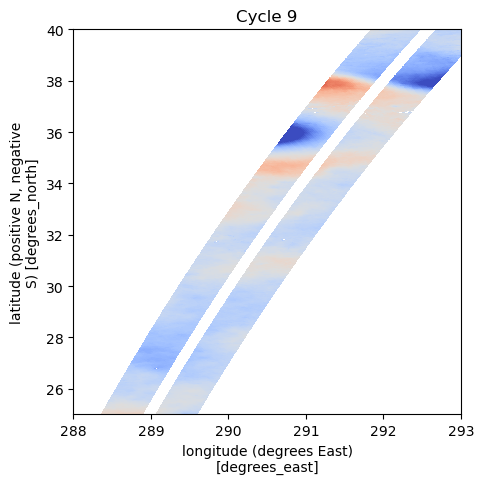

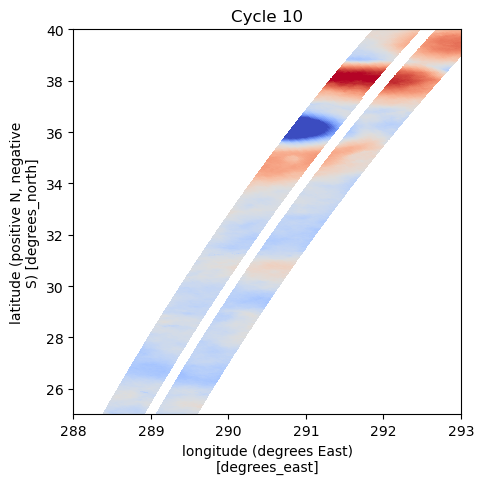

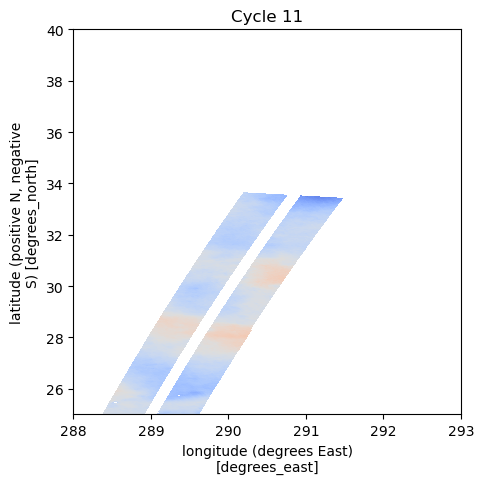

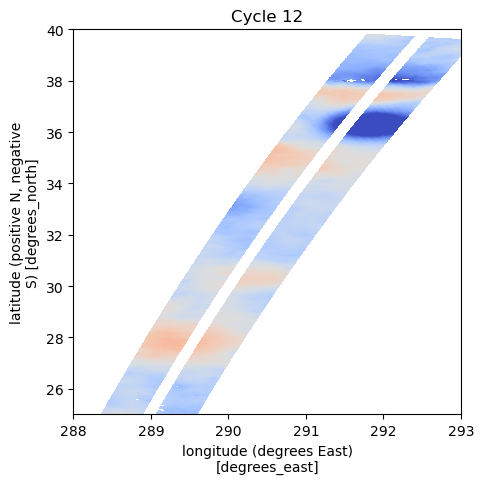

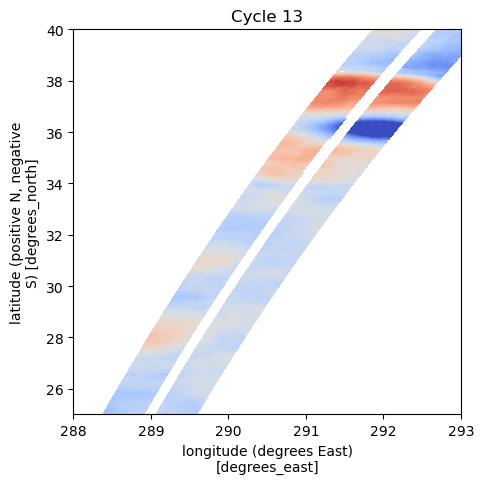

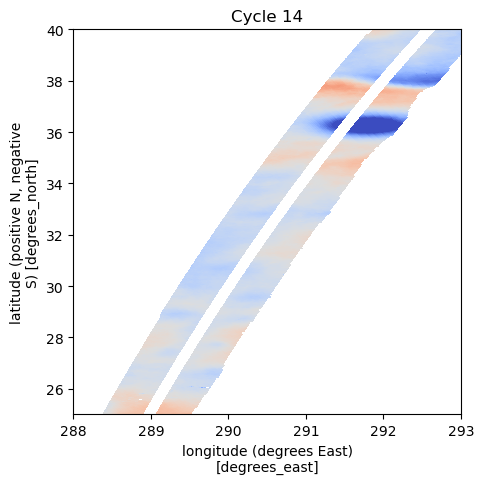

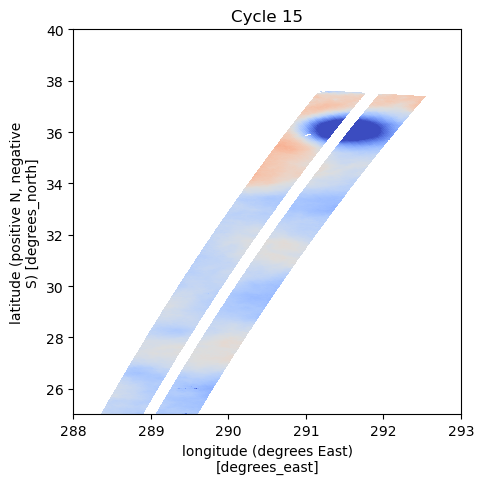

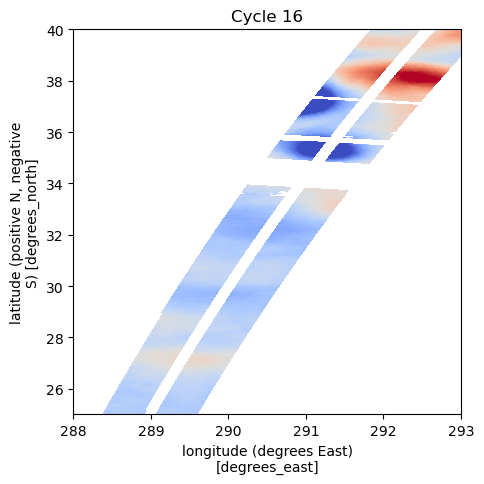

In [14]:
for c in _ds.cycles:
    fig,ax=plt.subplots(figsize=(5,5))
    ssha.sel(cycles=c).plot(ax=ax,x='longitude',y='latitude',cmap='coolwarm',vmax=0.5,add_colorbar=False)
    ax.set_title('Cycle %s'%c.values)
    #ssha.sel(cycles=c,passes=1).plot(ax=ax,x='longitude',y='latitude',cmap='coolwarm',vmax=0.5)
    ax.set_xlim(288,293);ax.set_ylim(25,40)

In [15]:
latmax,latmin = 40,25
lonmax,lonmin = 293,288
ssha = ssha.sel(cycles=[5,6,7,8,9,10,12,13])
ssha = ssha.where((ssha.latitude>latmin)&(ssha.latitude<latmax)&(ssha.longitude>lonmin)&(ssha.longitude<lonmax),drop=True)

In [16]:
# SWOT effective posting
DX_KM = 2.0

# Fu & Smith style averaging adapted for SWOT
SEGMENT_LENGTH_KM = 1024.0

# minimum valid fraction for keeping a profile
MIN_VALID_FRAC = 0.90


In [17]:
swath_mask = np.isfinite(ssha).mean(dim=['num_lines','cycles'])
id_gap = np.where(np.diff(np.flatnonzero(swath_mask))!=1)
left_start = np.flatnonzero(swath_mask)[0]
left_end = np.flatnonzero(swath_mask)[id_gap][0]
right_start = np.flatnonzero(swath_mask)[id_gap[0]+1][0]
right_end = np.flatnonzero(swath_mask)[-1]

In [18]:
# contiguous valid regions
ssha_left = ssha.isel(num_pixels=slice(left_start,left_end))
ssha_right = ssha.isel(num_pixels=slice(right_start,right_end))

In [19]:
def fill_small_gaps(arr):
    da = xr.DataArray(arr,dims=["num_lines","num_pixels"])
    da = da.interpolate_na(dim="num_lines",method="linear")#,max_gap={'along':3})
    #da = da.interpolate_na(dim="num_pixels",method="linear",limit=20)#,max_gap={'along':3})
    return da.values

def along_track_spectrum(ssh_side, lat_side, dx=2.0, segment_length=256.0,return_segments=False,idx=0.8):
    ssh_side = fill_small_gaps(ssh_side)
    lat_side = fill_small_gaps(lat_side)
    # Spectra parameters
    nperseg = int(segment_length / dx) #segment length
    noverlap = nperseg // 2 # overlap proportion
    step = nperseg - noverlap

    window = get_window("hann", nperseg)
    win_norm = np.sum(window**2)

    all_spectra = []   # store averaged segments results
    all_segment_spectra = []   # store per-segment results
    all_segment_lat = []   # store per-segment mean latitude
    kx_ref = None

    #Loop over all tracks in swath
    for j in range(ssh_side.shape[1]):
        #print("NaNs before:", np.sum(~np.isfinite(ssh_side[:, j])))
        #ssh_side[:, j] = fill_small_gaps(ssh_side[:, j])
        #lat_side[:, j] = fill_small_gaps(lat_side[:, j])
        profile = ssh_side[:, j]
        latitude = lat_side[:, j] 
        #print("NaNs after:", np.sum(~np.isfinite(profile)))
        valid_frac = np.sum(np.isfinite(profile)) / len(profile)

        if valid_frac < MIN_VALID_FRAC:
            continue

        profile = np.where(np.isfinite(profile), profile, np.nanmean(profile))
        profile = detrend(profile, type="linear") #remove linear trend

        segment_spectra = []
        segment_lat = []
        
        # slide over segments explicitly
        for start in range(0, len(profile) - nperseg + 1, step):
            seg = profile[start:start + nperseg]
            #seg = fill_small_gaps(seg)
            lat_seg = latitude[start:start+nperseg]
            #fill_small_gaps(latitude[start:start+nperseg])
            #print(np.any(~np.isfinite(seg)))
            frac_valid = np.mean(np.isfinite(seg))

            if frac_valid < 0.9:
                continue
            # Skip segments containing NaNs
            #if not np.all(np.isfinite(seg)):
            #    x = np.arange(len(seg))
            #    good = np.isfinite(seg)
            
             #   seg = np.interp(x, x[good], seg[good])
            #seg = detrend(seg, type="linear") #remove linear trend    
            seg = seg * window
            fft_seg = np.fft.rfft(seg)
            P = (np.abs(fft_seg) ** 2) / (win_norm * (1.0 / dx))

            kx = np.fft.rfftfreq(nperseg, d=dx)

            segment_spectra.append(P)
            segment_lat.append(np.mean(lat_seg))
        if len(segment_spectra) == 0:
            continue
        segment_spectra = np.asarray(segment_spectra)
        segment_lat = np.asarray(segment_lat)
        if kx_ref is None:
            kx_ref = kx

        # average over segments for this track
        P_mean = np.mean(segment_spectra, axis=0)

        all_spectra.append(P_mean)
        all_segment_spectra.append(segment_spectra)
        all_segment_lat.append(segment_lat)

    all_segment_spectra = np.asarray(all_segment_spectra)
    all_segment_lat = np.asarray(all_segment_lat)
    
    all_spectra = np.asarray(all_spectra)
    std_along = np.nanstd(all_spectra, axis=0)
    n_eff = np.sum(np.isfinite(all_spectra), axis=0)
    stderr_along = std_along / np.sqrt(n_eff)
    Ealong = np.nanmean(all_spectra, axis=0)

    if return_segments:
        return kx_ref, Ealong, stderr_along, all_segment_spectra, all_segment_lat
    else:
        return kx_ref, Ealong, stderr_along

In [32]:
SEGMENT_LENGTH_KM = 1024.0
spectra_L,spectra_R = [],[]
for c in ssha.cycles:
    kx_L, Ealong_L, stderr_L, all_seg_L,lat_L = along_track_spectrum(ssha_left.sel(cycles=c),ssha_left.sel(cycles=c).latitude,
                                                                     dx=DX_KM,segment_length=SEGMENT_LENGTH_KM,
                                                                     return_segments=True,)
    kx_R, Ealong_R, stderr_R, all_seg_R,lat_R = along_track_spectrum(ssha_right.sel(cycles=c),ssha_right.sel(cycles=c).latitude,
                                                                     dx=DX_KM,segment_length=SEGMENT_LENGTH_KM,
                                                                     return_segments=True,)
    if kx_L is None:
        continue
    Ealong_L = xr.Dataset({'spectra':(['k'],Ealong_L),'k':(['k'],kx_L)})
    Ealong_R = xr.Dataset({'spectra':(['k'],Ealong_R),'k':(['k'],kx_R)})
    spectra_L.append(Ealong_L)
    spectra_R.append(Ealong_R)
ds_L = xr.concat(spectra_L, dim='cycles')
ds_R = xr.concat(spectra_R, dim='cycles')

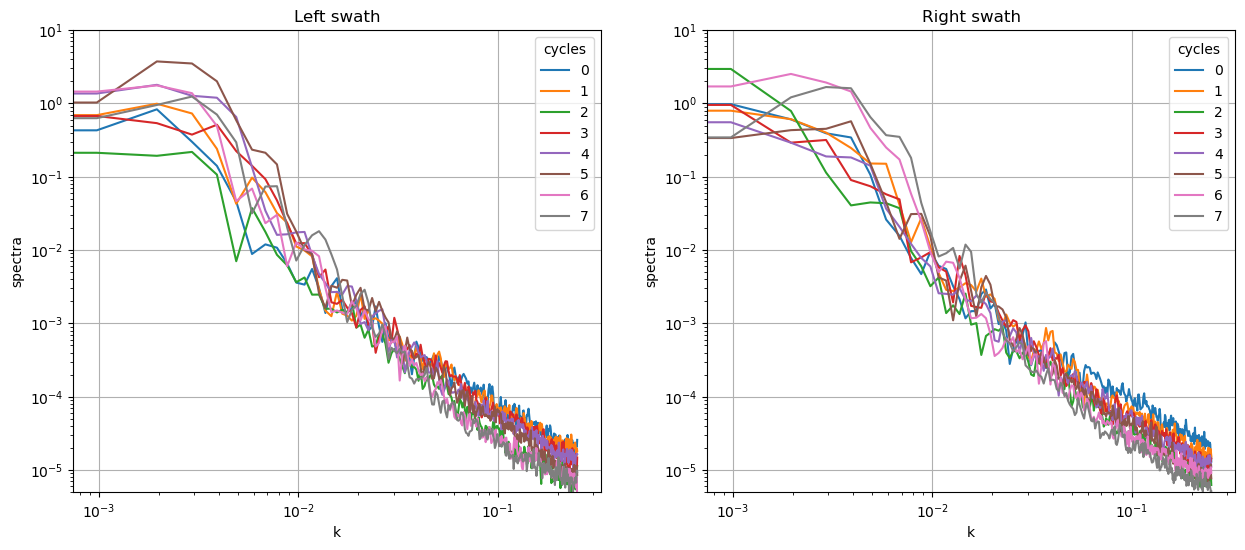

In [33]:
fig,axs= plt.subplots(1,2,figsize=(15,6))
ax=axs[0]
ds_L.spectra.plot(ax=ax,yscale='log',xscale='log',hue='cycles')
ax.set_title('Left swath')
ax=axs[1]
ds_R.spectra.plot(ax=ax,yscale='log',xscale='log',hue='cycles')
ax.set_title('Right swath')
for ax in axs:
    ax.set_ylim(5e-6,10);
    ax.grid()

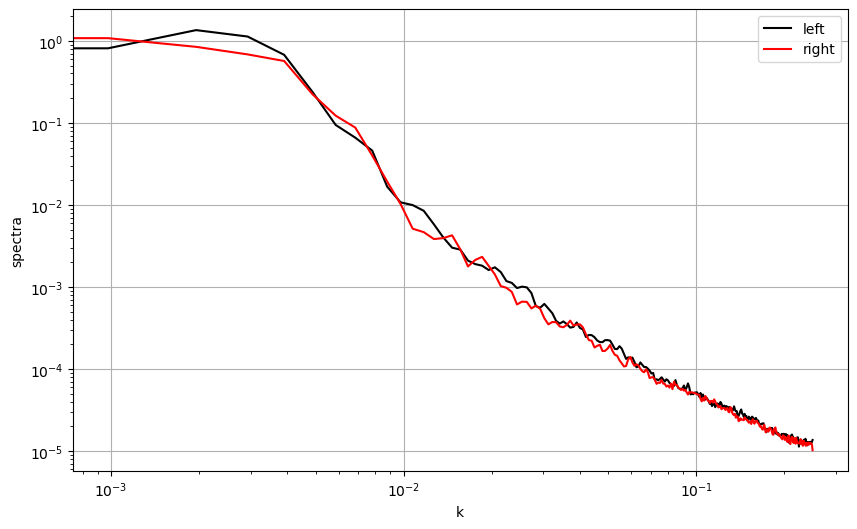

In [34]:
fig,ax= plt.subplots(figsize=(10,6))
ds_L.spectra.mean('cycles').plot(ax=ax,yscale='log',xscale='log',c='k',label='left')
ds_R.spectra.mean('cycles').plot(ax=ax,yscale='log',xscale='log',c='r',label='right')
ax.grid();ax.legend()

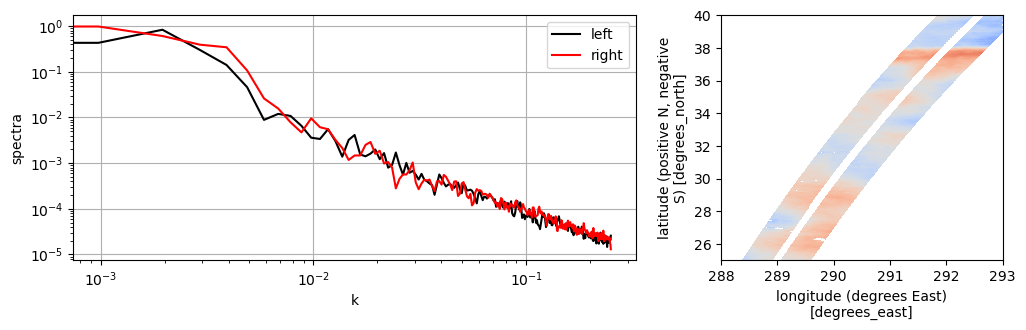

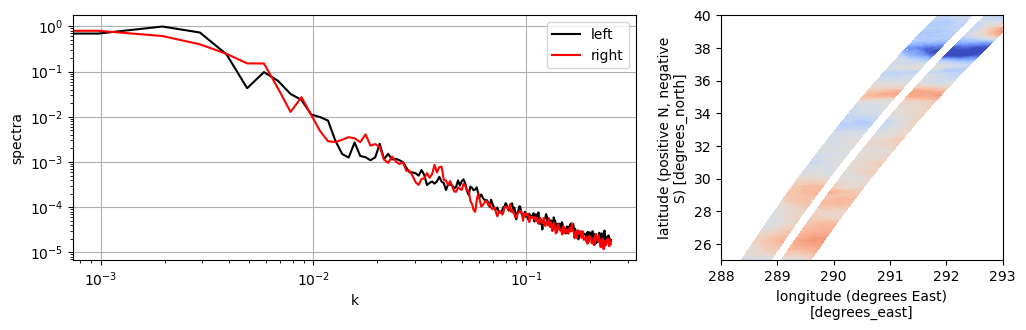

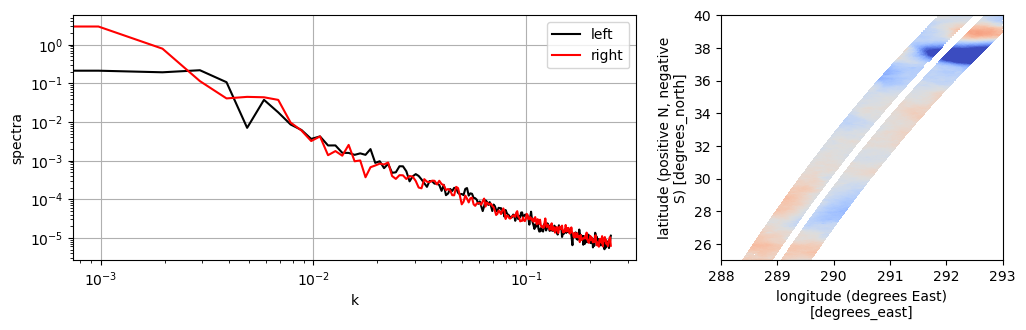

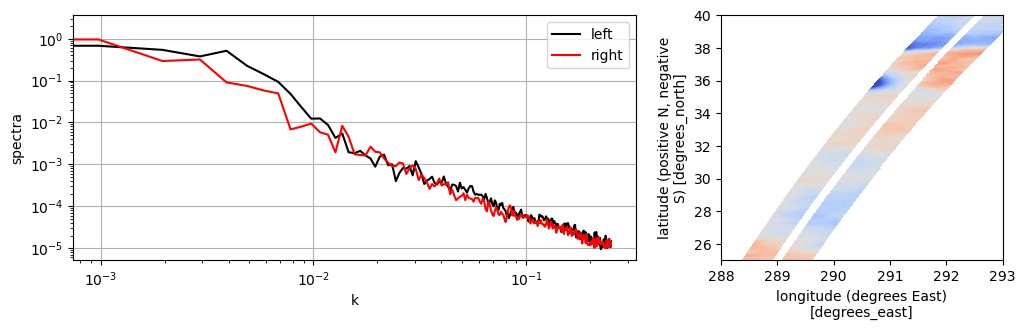

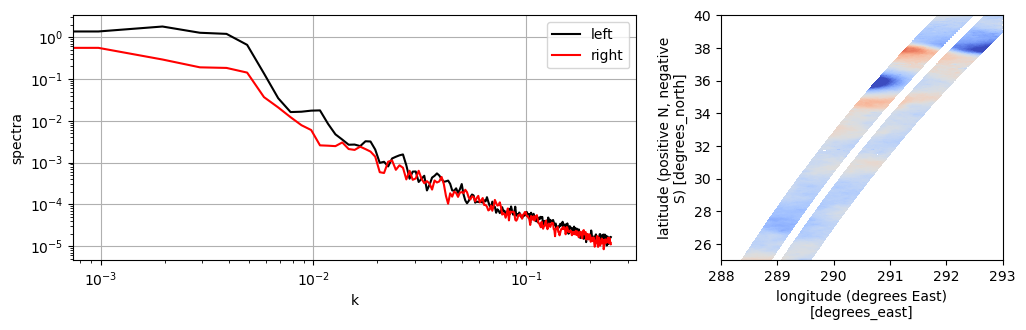

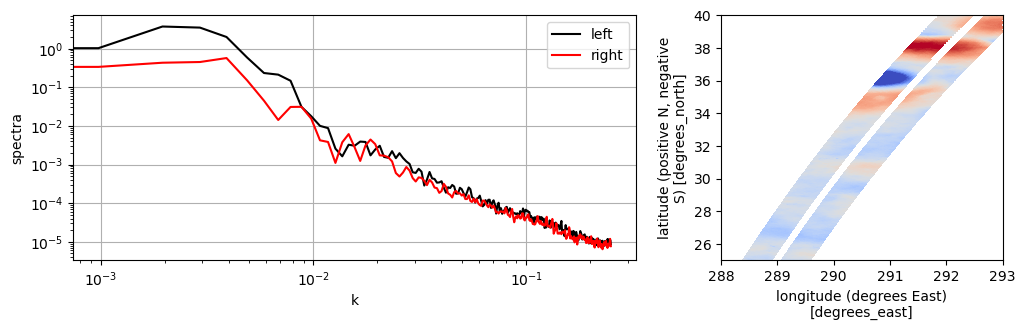

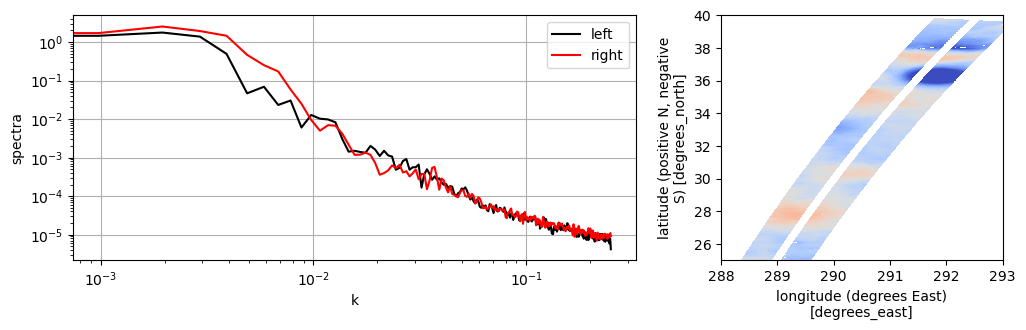

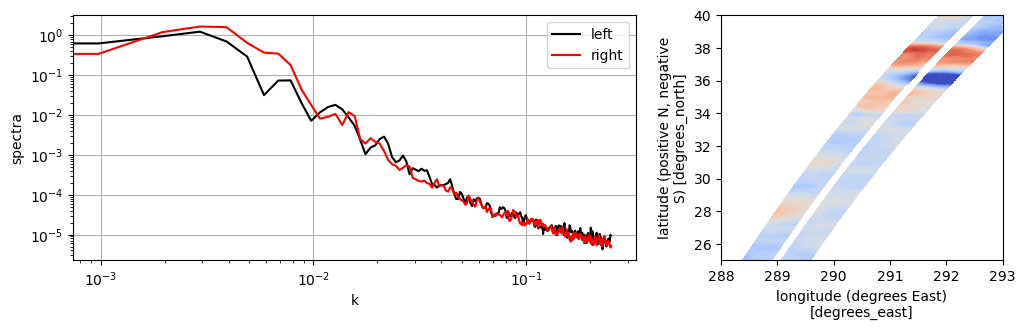

In [39]:
from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 2, width_ratios=[2, 1], height_ratios=[2, 2])
c=0

for c in range(0,ds_L.cycles.size):
    #fig,ax= plt.gri(1,2,figsize=(1,6))
    fig = plt.figure(figsize=(12,7))
    ax=fig.add_subplot(gs[0])
    ds_L.spectra.sel(cycles=c).plot(ax=ax,yscale='log',xscale='log',c='k',label='left')
    ds_R.spectra.sel(cycles=c).plot(ax=ax,yscale='log',xscale='log',c='r',label='right')
    ax.grid();ax.legend()
    ax = fig.add_subplot(gs[1])
    ssha.sel(cycles=c).plot(ax=ax,x='longitude',y='latitude',cmap='coolwarm',vmax=0.5,add_colorbar=False)
    ax.set_xlim(lonmin,lonmax);ax.set_ylim(latmin,latmax)

## submesoscale

In [40]:
SEGMENT_LENGTH_KM = 256.0
spectra_L,spectra_R = [],[]
for c in ssha.cycles:
    kx_L, Ealong_L, stderr_L, all_seg_L,lat_L = along_track_spectrum(ssha_left.sel(cycles=c),ssha_left.sel(cycles=c).latitude,
                                                                     dx=DX_KM,segment_length=SEGMENT_LENGTH_KM,
                                                                     return_segments=True,)
    kx_R, Ealong_R, stderr_R, all_seg_R,lat_R = along_track_spectrum(ssha_right.sel(cycles=c),ssha_right.sel(cycles=c).latitude,
                                                                     dx=DX_KM,segment_length=SEGMENT_LENGTH_KM,
                                                                     return_segments=True,)
    if kx_L is None:
        continue
    Ealong_L = xr.Dataset({'spectra':(['k'],Ealong_L),'k':(['k'],kx_L)})
    Ealong_R = xr.Dataset({'spectra':(['k'],Ealong_R),'k':(['k'],kx_R)})
    spectra_L.append(Ealong_L)
    spectra_R.append(Ealong_R)
ds_L = xr.concat(spectra_L, dim='cycles')
ds_R = xr.concat(spectra_R, dim='cycles')

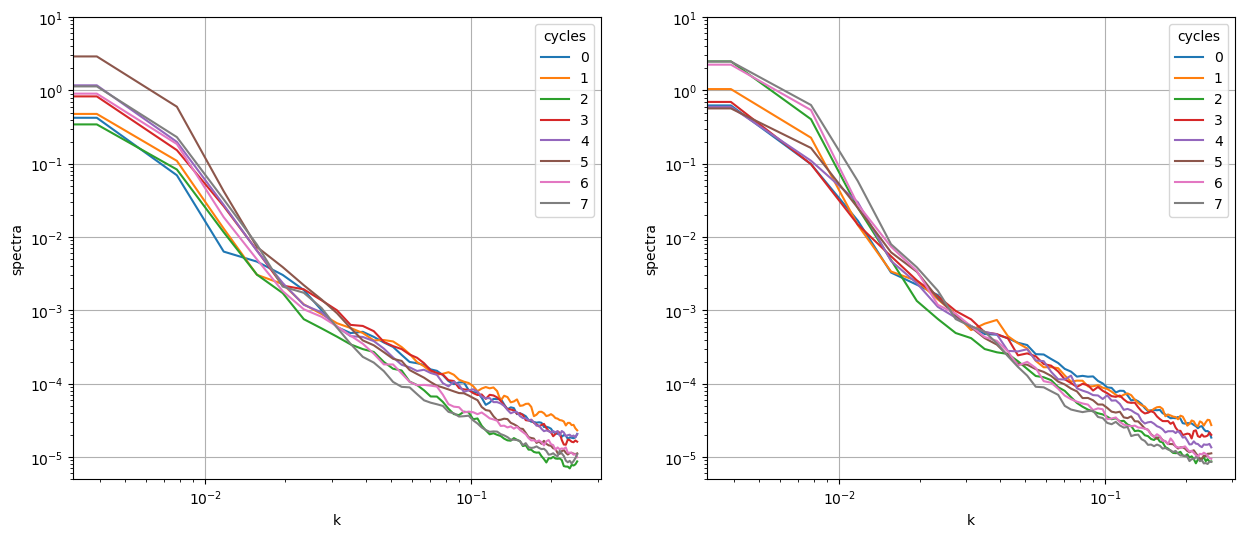

In [41]:
fig,axs= plt.subplots(1,2,figsize=(15,6))
ax=axs[0]
ds_L.spectra.plot(ax=ax,yscale='log',xscale='log',hue='cycles')
ax=axs[1]
ds_R.spectra.plot(ax=ax,yscale='log',xscale='log',hue='cycles')
for ax in axs:
    ax.set_ylim(5e-6,10);
    ax.grid()

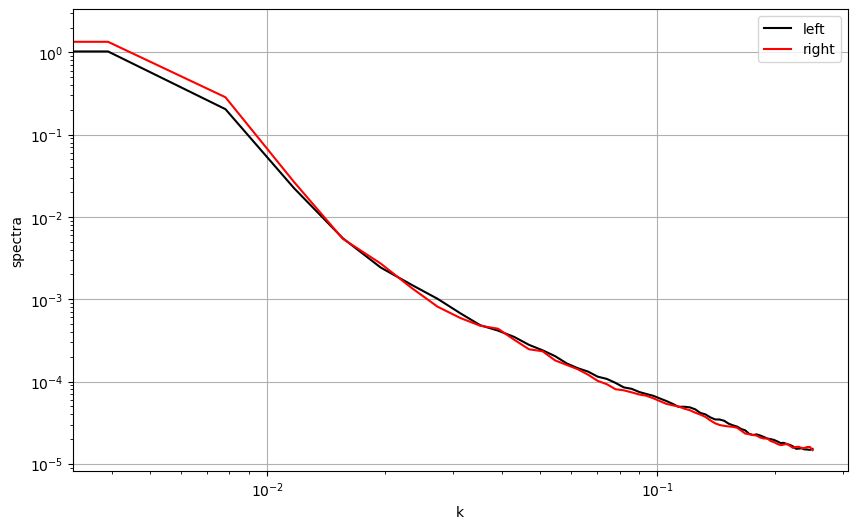

In [42]:
fig,ax= plt.subplots(figsize=(10,6))
ds_L.spectra.mean('cycles').plot(ax=ax,yscale='log',xscale='log',c='k',label='left')
ds_R.spectra.mean('cycles').plot(ax=ax,yscale='log',xscale='log',c='r',label='right')
ax.grid();ax.legend()

Notes: Good news!! (kinda) Looks like a large scale problem overall

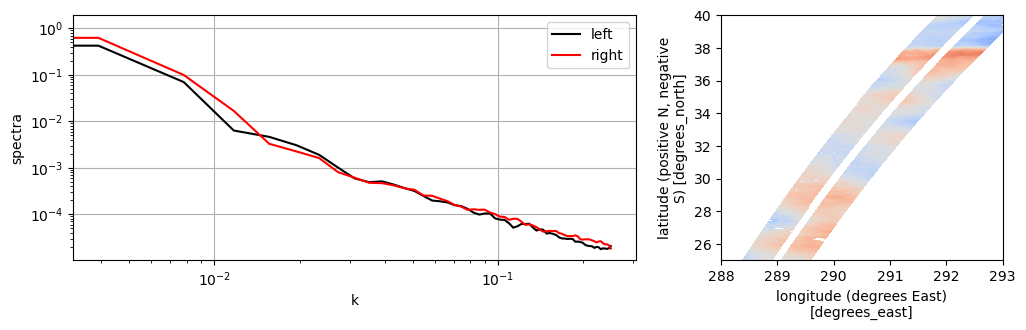

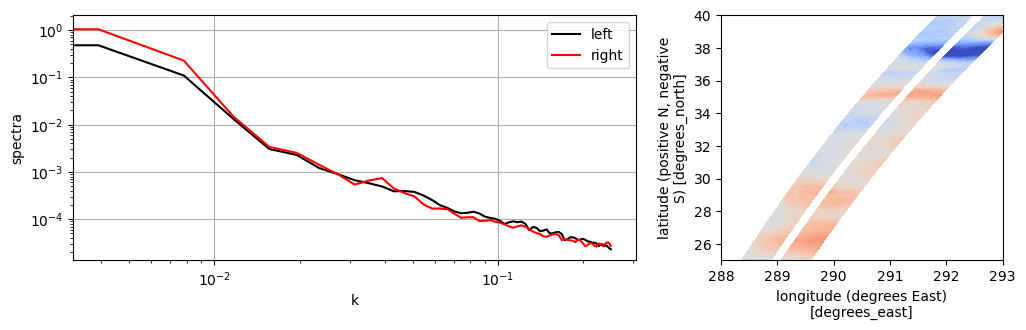

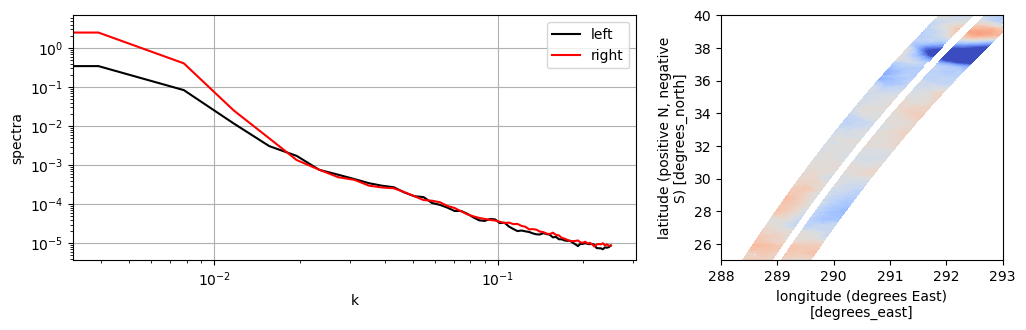

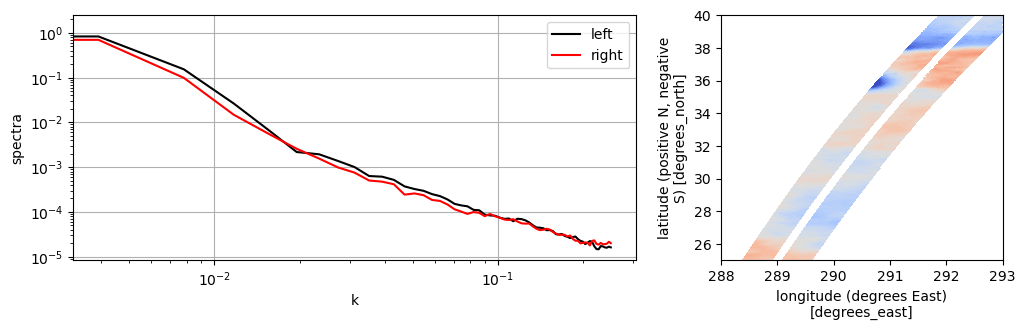

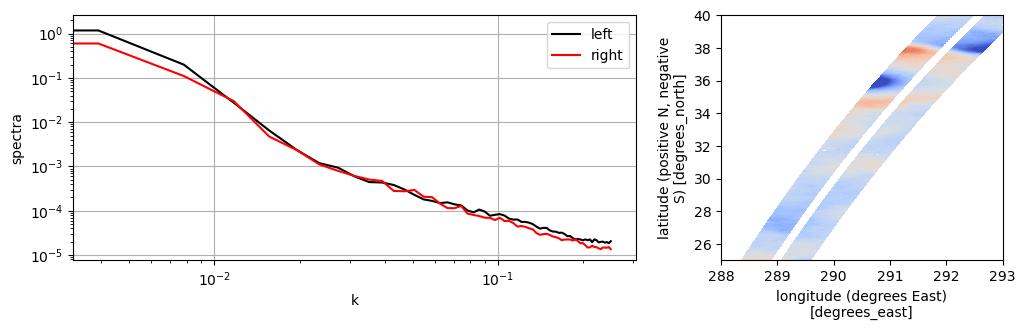

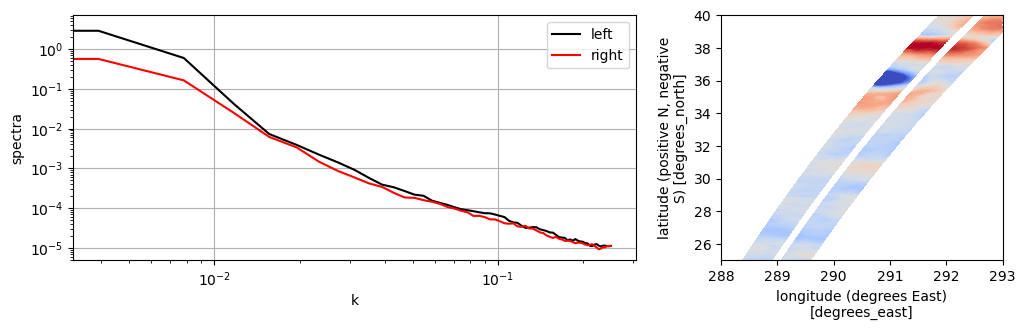

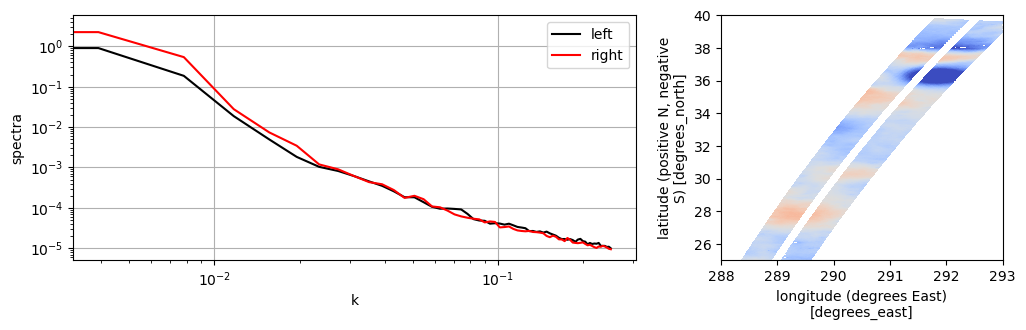

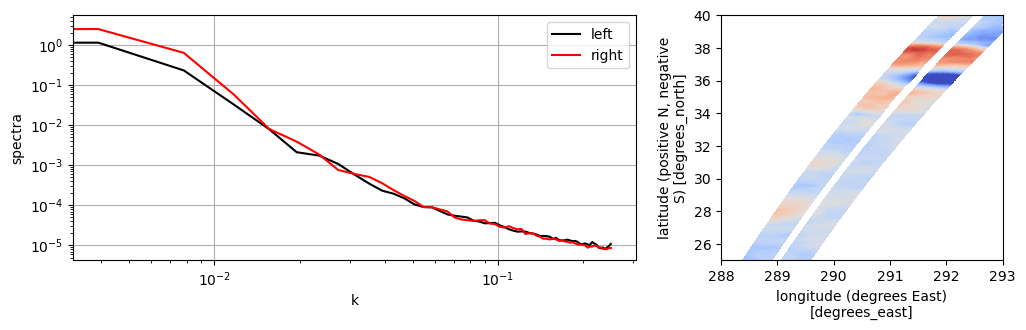

In [43]:
gs = GridSpec(2, 2, width_ratios=[2, 1], height_ratios=[2, 2])
c=0

for c in range(0,ds_L.cycles.size):
    #fig,ax= plt.gri(1,2,figsize=(1,6))
    fig = plt.figure(figsize=(12,7))
    ax=fig.add_subplot(gs[0])
    ds_L.spectra.sel(cycles=c).plot(ax=ax,yscale='log',xscale='log',c='k',label='left')
    ds_R.spectra.sel(cycles=c).plot(ax=ax,yscale='log',xscale='log',c='r',label='right')
    ax.grid();ax.legend()
    ax = fig.add_subplot(gs[1])
    ssha.sel(cycles=c).plot(ax=ax,x='longitude',y='latitude',cmap='coolwarm',vmax=0.5,add_colorbar=False)
    ax.set_xlim(lonmin,lonmax);ax.set_ylim(latmin,latmax)